# MSCS 634 Lab 1: Data Visualization, Preprocessing, and Statistical Analysis

Student Name:Aashish Shrestha
Course:Advance Big Data and Data Mining MSCS-634-M50
Lab Assignment:Data Visualization, Data Preprocessing, and Statistical Analysis


### About this notebook
This lab works with a **retail sales dataset** (`sales_data.csv`) that I created myself, so the
work here is original. The dataset was intentionally built with some **missing values** and a few
**outliers** so that every preprocessing technique in the lab has real data to act on.

The notebook is organised in the four required steps:

1. **Data Collection** &ndash; load the data and preview it.
2. **Data Visualization** &ndash; scatter, line, bar, histogram, box, and pie plots with insights.
3. **Data Preprocessing** &ndash; missing values, outliers (IQR), data reduction, scaling & discretization.
4. **Statistical Analysis** &ndash; overview, central tendency, dispersion, and correlation.


## Step 1: Data Collection

I load the dataset into a Pandas DataFrame and preview the first five rows with `.head()`.


In [ ]:
# Core libraries used throughout the lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling + inline display
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Load the self-created dataset into a DataFrame
df = pd.read_csv("sales_data.csv", parse_dates=["Order_Date"])

print("Dataset loaded.")
print("Rows, Columns:", df.shape)

Dataset loaded.
Rows, Columns: (600, 12)


**Screenshot #1 &ndash; First five rows of the dataset (`.head()`):**

In [ ]:
# Preview the first five records
df.head()

,Order_ID,Order_Date,Region,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Sales_Rep,Total_Sales,Shipping_Cost
0,ORD-10177,2023-01-02,South,Toys,Board Game,24,60.080000,25.0,3.8,Carlos,1081.44,14.65
1,ORD-10108,2023-01-06,East,Clothing,Denim Jeans,7,60.700000,20.0,5.0,Emma,339.92,11.49
2,ORD-10200,2023-01-06,North,Furniture,Study Desk,18,342.100000,20.0,2.8,Emma,4926.24,25.43
3,ORD-10599,2023-01-08,Central,Clothing,Denim Jeans,30,2433.388357,25.0,2.6,Carlos,54751.24,26.27
4,ORD-10559,2023-01-09,Central,Toys,RC Car,406,76.430000,0.0,3.2,Diana,31030.58,206.34


In [ ]:
# Quick look at column names and data types
df.dtypes

Order_ID                       str
Order_Date          datetime64[us]
Region                         str
Product_Category               str
Product_Name                   str
Units_Sold                   int64
Unit_Price                 float64
Discount_Percent           float64
Customer_Rating            float64
Sales_Rep                      str
Total_Sales                float64
Shipping_Cost              float64
dtype: object

## Step 2: Data Visualization

Below are six visualizations that explore the dataset from different angles. Each plot is followed
by a short written **insight**. (The lab requires at least two &ndash; I included the full set so the
exploration is thorough.) Every figure is also saved into the `screenshots/` folder.


### 2.1 Scatter Plot &ndash; Unit Price vs. Total Sales
Shows the relationship between two numeric variables.

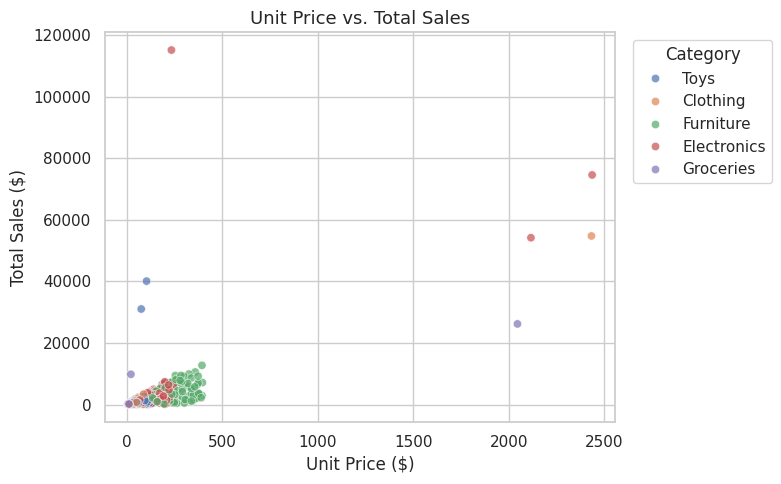

In [ ]:
plt.figure()
sns.scatterplot(data=df, x="Unit_Price", y="Total_Sales",
                hue="Product_Category", alpha=0.7)
plt.title("Unit Price vs. Total Sales")
plt.xlabel("Unit Price ($)")
plt.ylabel("Total Sales ($)")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("screenshots/01_scatter_price_vs_sales.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Total sales generally rise as unit price increases, which is expected. A small number
of points sit far away from the main cluster (very high price and/or total sales) &ndash; these are the
**outliers** that the preprocessing step will detect and handle.

### 2.2 Line Plot &ndash; Monthly Total Sales Over Time
Visualizes a trend across a time sequence.

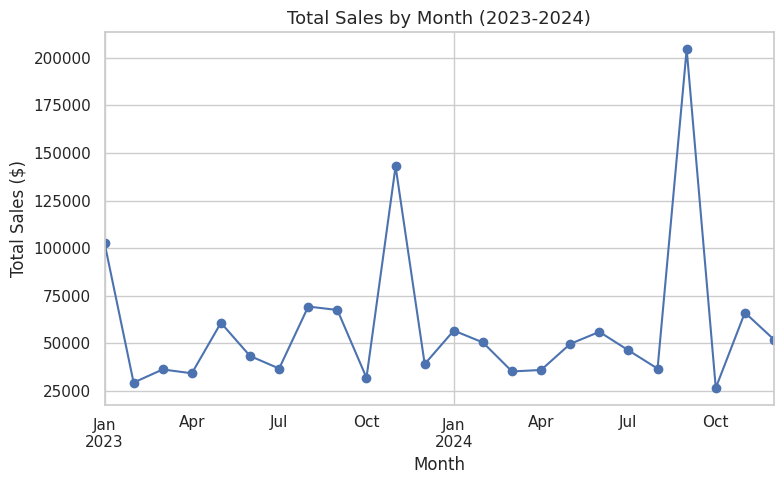

In [ ]:
monthly_sales = (df.set_index("Order_Date")["Total_Sales"]
                   .resample("ME").sum())

plt.figure()
monthly_sales.plot(marker="o")
plt.title("Total Sales by Month (2023-2024)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("screenshots/02_line_monthly_sales.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Monthly sales fluctuate throughout the two-year period rather than following one
steady line. The spikes line up with months that contain high-value (outlier) orders, so the trend
should be re-checked after outliers are removed.

### 2.3 Bar Chart &ndash; Total Sales by Product Category
Compares a numeric measure across categories.

/tmp/ipykernel_91/2595563164.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="viridis")


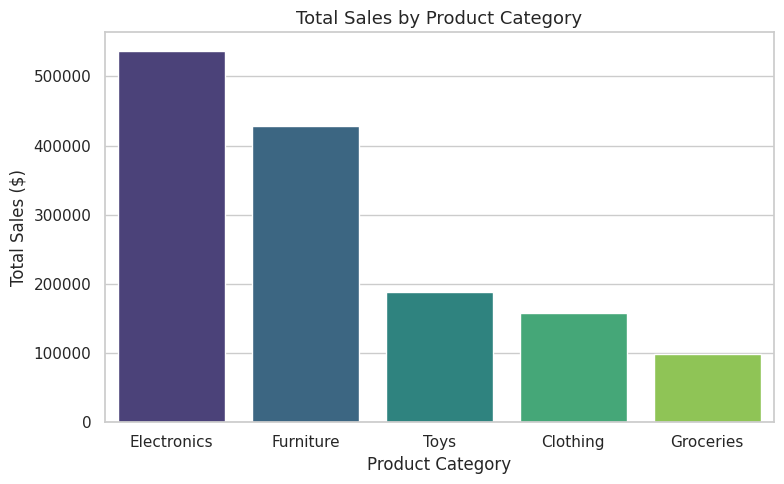

In [ ]:
cat_sales = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="viridis")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("screenshots/03_bar_sales_by_category.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** The categories do not contribute equally to revenue. The leading category earns
noticeably more than the lowest one, which tells the business where most of its sales value is
concentrated.

### 2.4 Histogram &ndash; Distribution of Units Sold
Shows the distribution of a numeric variable.

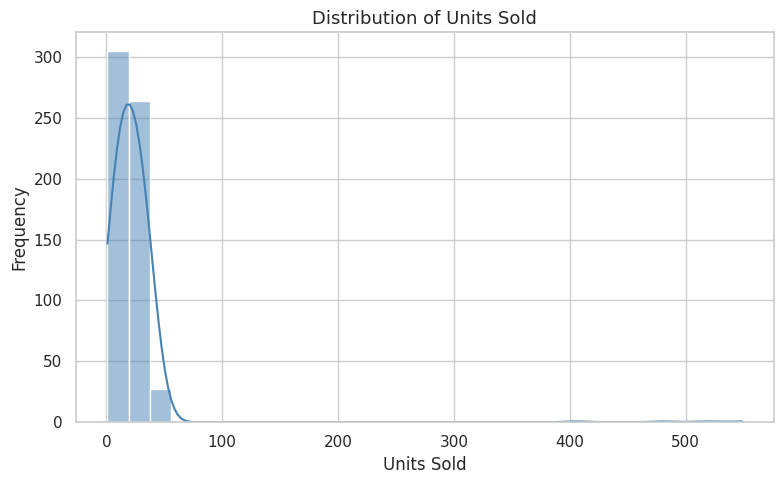

In [ ]:
plt.figure()
sns.histplot(df["Units_Sold"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("screenshots/04_hist_units_sold.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Most orders sell a small number of units (roughly 1&ndash;40), so the distribution is
strongly **right-skewed**. The long tail on the right is caused by a few unusually large orders &ndash;
another sign that outlier handling is needed.

### 2.5 Box Plot &ndash; Total Sales by Category
Displays spread and highlights outliers.

/tmp/ipykernel_91/2154957619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Product_Category", y="Total_Sales", palette="Set2")


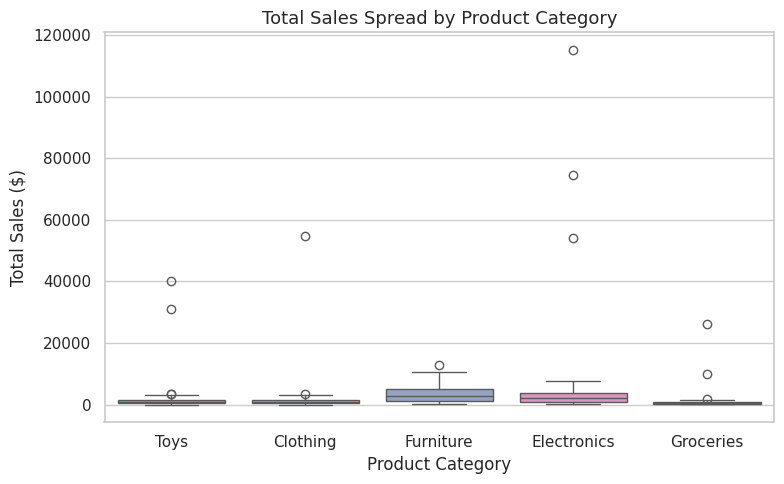

In [ ]:
plt.figure()
sns.boxplot(data=df, x="Product_Category", y="Total_Sales", palette="Set2")
plt.title("Total Sales Spread by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("screenshots/05_box_sales_by_category.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Every category shows points plotted well above the whiskers &ndash; these are the
statistical outliers. The box plot makes it obvious that a handful of extreme orders stretch the
scale for all categories.

### 2.6 Pie Chart &ndash; Share of Orders by Region
Represents proportions of a categorical variable.

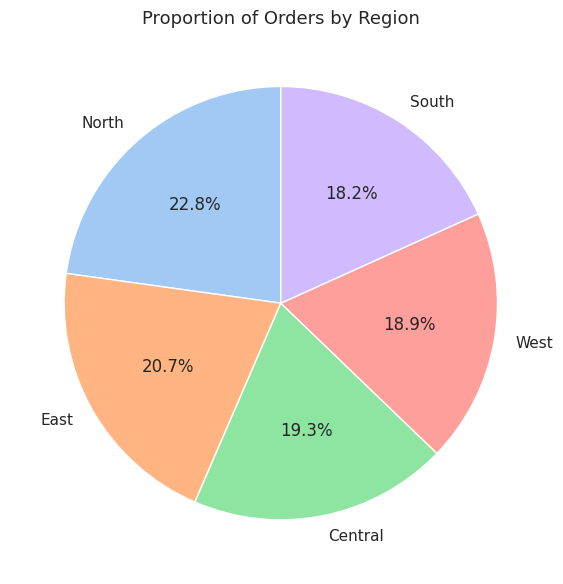

In [ ]:
region_counts = df["Region"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(region_counts.values, labels=region_counts.index,
        autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("pastel"))
plt.title("Proportion of Orders by Region")
plt.tight_layout()
plt.savefig("screenshots/06_pie_orders_by_region.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** Orders are spread fairly evenly across the regions, with no single region
dominating. (This chart ignores the missing `Region` values, which are handled in the next step.)

## Step 3: Data Preprocessing

This section cleans and prepares the data: handling missing values, detecting and removing outliers
with the IQR method, reducing the data, and finally scaling and discretizing.


### 3.1 Handling Missing Values

First I detect and report the missing values, then fill them using appropriate strategies:
- **`Customer_Rating`** (continuous numeric) &rarr; filled with the **mean**.
- **`Discount_Percent`** (discrete numeric) &rarr; filled with the **mode**.
- **`Region`** (categorical) &rarr; filled with the **mode**.

**Screenshot #2a &ndash; Missing values BEFORE handling:**

In [ ]:
# Detect and report missing values
print("Missing values per column (BEFORE):")
print(df.isnull().sum())

Missing values per column (BEFORE):
Order_ID             0
Order_Date           0
Region              30
Product_Category     0
Product_Name         0
Units_Sold           0
Unit_Price           0
Discount_Percent    48
Customer_Rating     60
Sales_Rep            0
Total_Sales          0
Shipping_Cost        0
dtype: int64


I also demonstrate **forward fill**, **backward fill**, and **row dropping** for completeness
(shown on copies so the main DataFrame is not affected).

In [ ]:
# --- Demonstrations of other techniques (on copies) ---
ffill_demo = df["Customer_Rating"].ffill()   # forward fill
bfill_demo = df["Customer_Rating"].bfill()   # backward fill
dropped_rows = df.dropna()                    # drop any row containing a missing value

print("Forward fill  -> remaining missing in Customer_Rating:", ffill_demo.isnull().sum())
print("Backward fill -> remaining missing in Customer_Rating:", bfill_demo.isnull().sum())
print("Drop rows     -> shape after dropping rows with any NaN:", dropped_rows.shape)

Forward fill  -> remaining missing in Customer_Rating: 0
Backward fill -> remaining missing in Customer_Rating: 0
Drop rows     -> shape after dropping rows with any NaN: (470, 12)


In [ ]:
# --- The strategy actually applied ---
df_filled = df.copy()

# Continuous numeric -> mean
mean_rating = round(df_filled["Customer_Rating"].mean(), 2)
df_filled["Customer_Rating"] = df_filled["Customer_Rating"].fillna(mean_rating)

# Discrete numeric -> mode
mode_discount = df_filled["Discount_Percent"].mode()[0]
df_filled["Discount_Percent"] = df_filled["Discount_Percent"].fillna(mode_discount)

# Categorical -> mode
mode_region = df_filled["Region"].mode()[0]
df_filled["Region"] = df_filled["Region"].fillna(mode_region)

print(f"Filled Customer_Rating with mean = {mean_rating}")
print(f"Filled Discount_Percent with mode = {mode_discount}")
print(f"Filled Region with mode = '{mode_region}'")

Filled Customer_Rating with mean = 3.7
Filled Discount_Percent with mode = 5.0
Filled Region with mode = 'North'


**Screenshot #2b &ndash; Missing values AFTER handling (all zeros):**

In [ ]:
print("Missing values per column (AFTER):")
print(df_filled.isnull().sum())

Missing values per column (AFTER):
Order_ID            0
Order_Date          0
Region              0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
Discount_Percent    0
Customer_Rating     0
Sales_Rep           0
Total_Sales         0
Shipping_Cost       0
dtype: int64


### 3.2 Outlier Detection and Removal (IQR Method)

I use the **Interquartile Range (IQR)** on `Total_Sales`. Any value below
`Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is treated as an outlier.

**Screenshot #3 &ndash; IQR calculation, identified outliers, and dataset after removal:**

In [ ]:
col = "Total_Sales"

Q1 = df_filled[col].quantile(0.25)
Q3 = df_filled[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile) : {Q1:.2f}")
print(f"Q3 (75th percentile) : {Q3:.2f}")
print(f"IQR                  : {IQR:.2f}")
print(f"Lower bound          : {lower_bound:.2f}")
print(f"Upper bound          : {upper_bound:.2f}")

Q1 (25th percentile) : 437.96
Q3 (75th percentile) : 2324.07
IQR                  : 1886.11
Lower bound          : -2391.21
Upper bound          : 5153.25


In [ ]:
# Identify the outlier rows
outliers = df_filled[(df_filled[col] < lower_bound) | (df_filled[col] > upper_bound)]
print("Number of outliers detected in Total_Sales:", len(outliers))
outliers[["Order_ID", "Product_Category", "Units_Sold", "Unit_Price", "Total_Sales"]]

Number of outliers detected in Total_Sales: 48


,Order_ID,Product_Category,Units_Sold,Unit_Price,Total_Sales
3,ORD-10599,Clothing,30,2433.388357,54751.24
4,ORD-10559,Toys,406,76.430000,31030.58
37,ORD-10250,Furniture,39,268.320000,7848.36
70,ORD-10382,Furniture,36,258.350000,6975.45
105,ORD-10249,Furniture,37,185.800000,6530.87
111,ORD-10232,Furniture,32,252.160000,6051.84
118,ORD-10036,Electronics,39,243.660000,7602.19
147,ORD-10102,Furniture,34,273.690000,7909.64
167,ORD-10421,Furniture,30,218.660000,5575.83
194,ORD-10266,Groceries,549,22.390000,9833.69


In [ ]:
# Remove the outliers
df_no_outliers = df_filled[(df_filled[col] >= lower_bound) & (df_filled[col] <= upper_bound)].copy()

print("Shape BEFORE outlier removal:", df_filled.shape)
print("Shape AFTER  outlier removal:", df_no_outliers.shape)

Shape BEFORE outlier removal: (600, 12)
Shape AFTER  outlier removal: (552, 12)


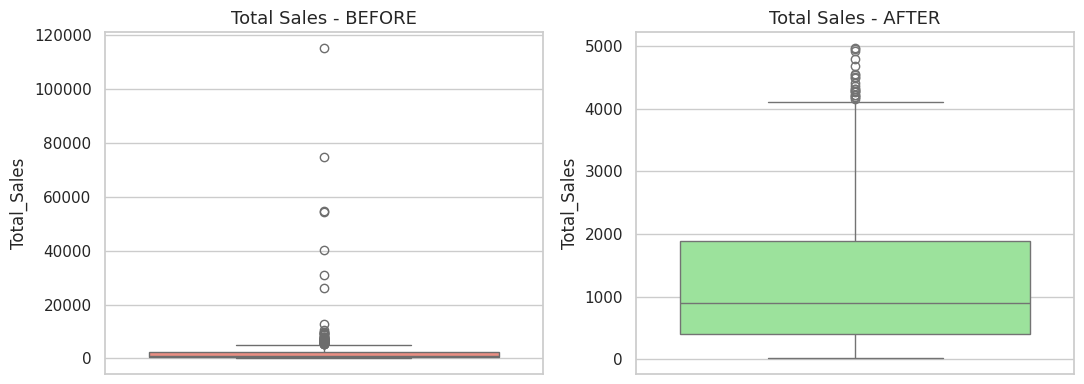

In [ ]:
# Visual confirmation: box plot before vs. after
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df_filled["Total_Sales"], ax=axes[0], color="salmon")
axes[0].set_title("Total Sales - BEFORE")
sns.boxplot(y=df_no_outliers["Total_Sales"], ax=axes[1], color="lightgreen")
axes[1].set_title("Total Sales - AFTER")
plt.tight_layout()
plt.savefig("screenshots/07_outliers_before_after.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.3 Data Reduction

Two forms of reduction:
- **Sampling** &ndash; take a fixed number of rows and a percentage of rows.
- **Dimension elimination** &ndash; drop columns that add little analytical value
  (`Order_ID`, `Sales_Rep`, `Shipping_Cost`).

**Screenshot #4 &ndash; Dataset before and after data reduction:**

In [ ]:
print("Original (cleaned) shape:", df_no_outliers.shape)

# Sampling by number of rows
sample_by_number = df_no_outliers.sample(n=100, random_state=1)
print("Sample by number (n=100)   :", sample_by_number.shape)

# Sampling by percentage
sample_by_percent = df_no_outliers.sample(frac=0.25, random_state=1)
print("Sample by percentage (25%) :", sample_by_percent.shape)

Original (cleaned) shape: (552, 12)
Sample by number (n=100)   : (100, 12)
Sample by percentage (25%) : (138, 12)


In [ ]:
# Dimension elimination - drop less relevant columns
cols_to_drop = ["Order_ID", "Sales_Rep", "Shipping_Cost"]
df_reduced = df_no_outliers.drop(columns=cols_to_drop)

print("Columns BEFORE:", list(df_no_outliers.columns))
print()
print("Columns AFTER :", list(df_reduced.columns))
print()
print("Shape BEFORE:", df_no_outliers.shape, "| Shape AFTER:", df_reduced.shape)

Columns BEFORE: ['Order_ID', 'Order_Date', 'Region', 'Product_Category', 'Product_Name', 'Units_Sold', 'Unit_Price', 'Discount_Percent', 'Customer_Rating', 'Sales_Rep', 'Total_Sales', 'Shipping_Cost']

Columns AFTER : ['Order_Date', 'Region', 'Product_Category', 'Product_Name', 'Units_Sold', 'Unit_Price', 'Discount_Percent', 'Customer_Rating', 'Total_Sales']

Shape BEFORE: (552, 12) | Shape AFTER: (552, 9)


In [ ]:
# Preview after reduction
df_reduced.head()

,Order_Date,Region,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales
0,2023-01-02,South,Toys,Board Game,24,60.08,25.0,3.8,1081.44
1,2023-01-06,East,Clothing,Denim Jeans,7,60.70,20.0,5.0,339.92
2,2023-01-06,North,Furniture,Study Desk,18,342.10,20.0,2.8,4926.24
5,2023-01-13,South,Clothing,Denim Jeans,38,37.46,15.0,3.6,1209.96
6,2023-01-14,North,Electronics,Bluetooth Speaker,7,221.62,5.0,3.1,1473.77


### 3.4 Data Scaling and Discretization

I scale the numeric columns three different ways and then discretize a continuous column
into meaningful categories.

- **Min-Max Scaling** &rarr; rescales values to the range [0, 1].
- **Z-score Standardization** &rarr; mean 0, standard deviation 1.
- **Decimal Scaling** &rarr; divides by a power of 10.
- **Discretization** &rarr; `Total_Sales` split into **Low / Medium / High** spending tiers.

**Screenshot #5 &ndash; Dataset before and after scaling / discretization:**

In [ ]:
num_cols = ["Units_Sold", "Unit_Price", "Discount_Percent", "Customer_Rating", "Total_Sales"]

print("BEFORE scaling (original numeric values):")
df_no_outliers[num_cols].head()

BEFORE scaling (original numeric values):


,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales
0,24,60.08,25.0,3.8,1081.44
1,7,60.70,20.0,5.0,339.92
2,18,342.10,20.0,2.8,4926.24
5,38,37.46,15.0,3.6,1209.96
6,7,221.62,5.0,3.1,1473.77


In [ ]:
# 1) Min-Max Scaling
minmax = (df_no_outliers[num_cols] - df_no_outliers[num_cols].min()) / \
         (df_no_outliers[num_cols].max() - df_no_outliers[num_cols].min())

print("AFTER Min-Max Scaling (range 0 to 1):")
minmax.head()

AFTER Min-Max Scaling (range 0 to 1):


,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales
0,0.605263,0.139735,1.0,0.52,0.215794
1,0.157895,0.141329,0.8,1.00,0.066499
2,0.447368,0.864945,0.8,0.12,0.989893
5,0.973684,0.081568,0.6,0.44,0.241670
6,0.157895,0.555133,0.2,0.24,0.294785


In [ ]:
# 2) Z-score Standardization
zscore = (df_no_outliers[num_cols] - df_no_outliers[num_cols].mean()) / df_no_outliers[num_cols].std()

print("AFTER Z-score Standardization (mean 0, std 1):")
zscore.head()

AFTER Z-score Standardization (mean 0, std 1):


,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales
0,0.467439,-0.373047,1.578475,0.126988,-0.181035
1,-1.095244,-0.365351,0.971285,1.909120,-0.814486
2,-0.084096,3.127397,0.971285,-1.358122,3.103427
5,1.754355,-0.653807,0.364094,-0.170034,-0.071245
6,-1.095244,1.631994,-0.850287,-0.912589,0.154117


In [ ]:
# 3) Decimal Scaling: divide each column by 10^j, where j depends on the max absolute value
decimal_scaled = df_no_outliers[num_cols].copy()
for c in num_cols:
    max_abs = df_no_outliers[c].abs().max()
    j = int(np.ceil(np.log10(max_abs))) if max_abs > 0 else 0
    decimal_scaled[c] = df_no_outliers[c] / (10 ** j)

print("AFTER Decimal Scaling:")
decimal_scaled.head()

AFTER Decimal Scaling:


,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales
0,0.24,0.06008,0.25,0.38,0.108144
1,0.07,0.06070,0.20,0.50,0.033992
2,0.18,0.34210,0.20,0.28,0.492624
5,0.38,0.03746,0.15,0.36,0.120996
6,0.07,0.22162,0.05,0.31,0.147377


In [ ]:
# Discretization: turn continuous Total_Sales into Low / Medium / High tiers
df_binned = df_no_outliers.copy()
df_binned["Sales_Tier"] = pd.qcut(df_binned["Total_Sales"], q=3,
                                  labels=["Low", "Medium", "High"])

print("Count of records in each Sales_Tier:")
print(df_binned["Sales_Tier"].value_counts())
print()
df_binned[["Total_Sales", "Sales_Tier"]].head()

Count of records in each Sales_Tier:
Sales_Tier
Low       184
Medium    184
High      184
Name: count, dtype: int64



,Total_Sales,Sales_Tier
0,1081.44,Medium
1,339.92,Low
2,4926.24,High
5,1209.96,Medium
6,1473.77,Medium


## Step 4: Statistical Analysis

Finally, I summarise the cleaned dataset (`df_no_outliers`) with descriptive statistics and a
correlation matrix.


### 4.1 General Overview of the Data

**Screenshot #6 &ndash; `.info()` and `.describe()` outputs:**

In [ ]:
# Structure, column types, and non-null counts
df_no_outliers.info()

<class 'pandas.DataFrame'>
Index: 552 entries, 0 to 599
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          552 non-null    str           
 1   Order_Date        552 non-null    datetime64[us]
 2   Region            552 non-null    str           
 3   Product_Category  552 non-null    str           
 4   Product_Name      552 non-null    str           
 5   Units_Sold        552 non-null    int64         
 6   Unit_Price        552 non-null    float64       
 7   Discount_Percent  552 non-null    float64       
 8   Customer_Rating   552 non-null    float64       
 9   Sales_Rep         552 non-null    str           
 10  Total_Sales       552 non-null    float64       
 11  Shipping_Cost     552 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(5)
memory usage: 56.1 KB


In [ ]:
# Summary statistics for numeric columns
df_no_outliers.describe()

,Order_Date,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales,Shipping_Cost
count,552,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000
mean,2023-12-24 07:33:54.782608,18.914855,90.135217,12.001812,3.714493,1293.359837,20.211703
min,2023-01-02 00:00:00,1.000000,5.740000,0.000000,2.500000,9.630000,5.470000
25%,2023-06-26 00:00:00,10.000000,34.185000,5.000000,3.200000,393.325000,11.835000
50%,2023-12-09 12:00:00,18.000000,62.680000,10.000000,3.700000,890.840000,18.810000
75%,2024-06-21 00:00:00,28.000000,118.655000,20.000000,4.200000,1884.045000,26.457500
max,2024-12-30 00:00:00,39.000000,394.620000,25.000000,5.000000,4976.440000,48.220000
std,NaN,10.878724,80.566935,8.234648,0.673351,1170.602843,9.993411


### 4.2 Central Tendency Measures
Minimum, Maximum, Mean, Median, and Mode for each numeric column.

**Screenshot #7 &ndash; Central tendency results:**

In [ ]:
num_cols = ["Units_Sold", "Unit_Price", "Discount_Percent", "Customer_Rating", "Total_Sales"]

central_tendency = pd.DataFrame({
    "Minimum": df_no_outliers[num_cols].min(),
    "Maximum": df_no_outliers[num_cols].max(),
    "Mean":    df_no_outliers[num_cols].mean().round(2),
    "Median":  df_no_outliers[num_cols].median(),
    "Mode":    df_no_outliers[num_cols].mode().iloc[0],
})
central_tendency

,Minimum,Maximum,Mean,Median,Mode
Units_Sold,1.00,39.00,18.91,18.00,16.00
Unit_Price,5.74,394.62,90.14,62.68,10.55
Discount_Percent,0.00,25.00,12.00,10.00,5.00
Customer_Rating,2.50,5.00,3.71,3.70,3.70
Total_Sales,9.63,4976.44,1293.36,890.84,1265.85


### 4.3 Dispersion Measures
Range, Quartiles (Q1/Q2/Q3), Interquartile Range (IQR), Variance, and Standard Deviation.

**Screenshot #8 &ndash; Dispersion results:**

In [ ]:
dispersion = pd.DataFrame({
    "Range":    (df_no_outliers[num_cols].max() - df_no_outliers[num_cols].min()).round(2),
    "Q1":       df_no_outliers[num_cols].quantile(0.25).round(2),
    "Q2 (Median)": df_no_outliers[num_cols].quantile(0.50).round(2),
    "Q3":       df_no_outliers[num_cols].quantile(0.75).round(2),
    "IQR":      (df_no_outliers[num_cols].quantile(0.75) - df_no_outliers[num_cols].quantile(0.25)).round(2),
    "Variance": df_no_outliers[num_cols].var().round(2),
    "Std Dev":  df_no_outliers[num_cols].std().round(2),
})
dispersion

,Range,Q1,Q2 (Median),Q3,IQR,Variance,Std Dev
Units_Sold,38.00,10.00,18.00,28.00,18.00,118.35,10.88
Unit_Price,388.88,34.18,62.68,118.66,84.47,6491.03,80.57
Discount_Percent,25.00,5.00,10.00,20.00,15.00,67.81,8.23
Customer_Rating,2.50,3.20,3.70,4.20,1.00,0.45,0.67
Total_Sales,4966.81,393.33,890.84,1884.04,1490.72,1370311.02,1170.60


### 4.4 Correlation Analysis
Correlation matrix for the numeric columns, shown as a table and a heatmap.

**Screenshot #9 &ndash; Correlation matrix:**

In [ ]:
correlation_matrix = df_no_outliers[num_cols].corr()
correlation_matrix.round(3)

,Units_Sold,Unit_Price,Discount_Percent,Customer_Rating,Total_Sales
Units_Sold,1.000,-0.253,0.045,-0.028,0.391
Unit_Price,-0.253,1.000,-0.020,-0.013,0.638
Discount_Percent,0.045,-0.020,1.000,-0.055,-0.070
Customer_Rating,-0.028,-0.013,-0.055,1.000,-0.065
Total_Sales,0.391,0.638,-0.070,-0.065,1.000


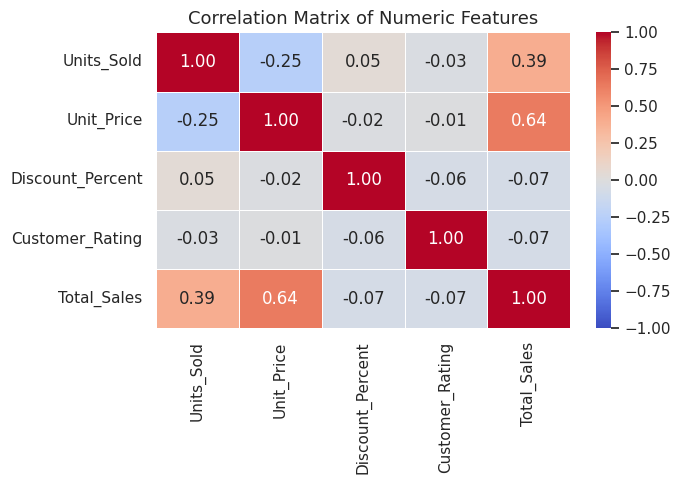

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig("screenshots/08_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight:** `Total_Sales` correlates most strongly with `Unit_Price` and `Units_Sold`, which makes
sense because total sales are calculated from them. `Discount_Percent` shows a mild negative
relationship with total sales, and `Customer_Rating` is largely independent of the other numeric
fields.

---

### Summary
The dataset was loaded, explored with six visualizations, cleaned (missing values filled, outliers
removed with IQR), reduced, scaled, and discretized, then described with central-tendency,
dispersion, and correlation statistics. The cleaned DataFrame `df_no_outliers` is ready for any
deeper modelling in later labs.
